## Load data

### imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
import warnings
import csv
from google.colab import drive
warnings.filterwarnings('ignore')

np.random.seed(42)

### data loading

In [2]:
drive.mount('/content/drive')
base_path = '/content/drive/My Drive/Colab Notebooks/netflix-prize-data/'

Mounted at /content/drive


In [3]:
def load_titles(path: str):
    titles = []
    with open(path, encoding='latin-1') as f:
        reader = csv.reader(f)
        for row in reader:
            try:
                movie_id = int(row[0])
                year = int(row[1])
                title = ",".join(row[2:])
                titles.append([movie_id, year, title])
            except:
                continue
    return pd.DataFrame(titles, columns=['movie_id', 'year', 'title'])


titles_df = load_titles(base_path+'movie_titles.csv')

In [4]:
def load_ratings(path: str):
    ratings_list = []
    with open(path, 'r') as file:
        movie_id = None
        for line in file:
            line = line.strip()
            if line.endswith(':'):
                movie_id = int(line[:-1])
            else:
                user_id, rating, date = line.split(',')
                ratings_list.append([int(user_id), movie_id, int(rating), date])

    return pd.DataFrame(ratings_list, columns=['user_id', 'movie_id', 'rating', 'date'])


ratings_df = load_ratings(base_path+'combined_data_1.txt')

In [5]:
df = pd.merge(ratings_df, titles_df, on='movie_id')

## Preview

In [6]:
df.shape

(24053575, 6)

In [7]:
df.head()

,user_id,movie_id,rating,date,year,title
0,1488844,1,3,2005-09-06,2003,Dinosaur Planet
1,822109,1,5,2005-05-13,2003,Dinosaur Planet
2,885013,1,4,2005-10-19,2003,Dinosaur Planet
3,30878,1,4,2005-12-26,2003,Dinosaur Planet
4,823519,1,3,2004-05-03,2003,Dinosaur Planet


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24053575 entries, 0 to 24053574
Data columns (total 6 columns):
 #   Column    Dtype 
---  ------    ----- 
 0   user_id   int64 
 1   movie_id  int64 
 2   rating    int64 
 3   date      object
 4   year      int64 
 5   title     object
dtypes: int64(4), object(2)
memory usage: 1.1+ GB


In [9]:
df.describe()

,user_id,movie_id,rating,year
count,2.405358e+07,2.405358e+07,2.405358e+07,2.405358e+07
mean,1.322286e+06,2.308308e+03,3.599639e+00,1.994406e+03
std,7.645780e+05,1.303901e+03,1.086117e+00,1.259927e+01
min,6.000000e+00,1.000000e+00,1.000000e+00,1.915000e+03
25%,6.609295e+05,1.180000e+03,3.000000e+00,1.991000e+03
50%,1.318594e+06,2.342000e+03,4.000000e+00,1.999000e+03
75%,1.984358e+06,3.433000e+03,4.000000e+00,2.003000e+03
max,2.649429e+06,4.499000e+03,5.000000e+00,2.005000e+03


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isnull().sum()

,0
user_id,0
movie_id,0
rating,0
date,0
year,0
title,0


In [12]:
df['date'] = pd.to_datetime(df['date'])

## Analysis

### ratings distribution

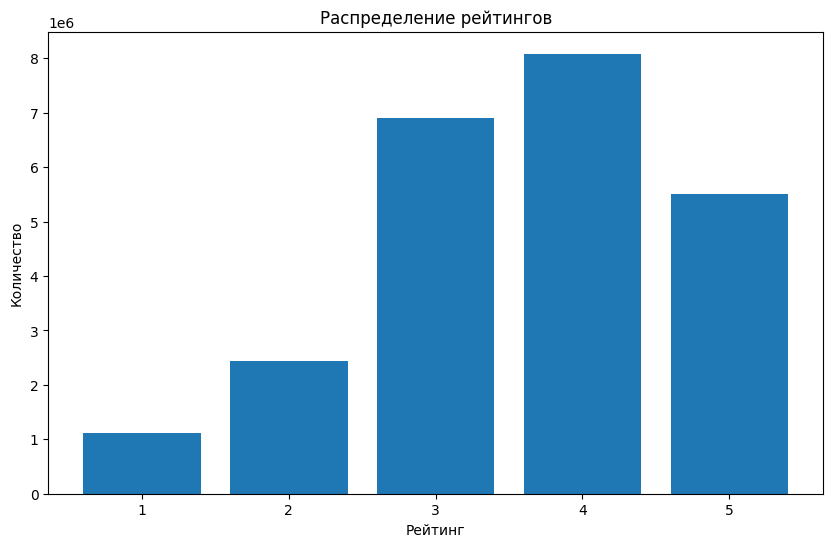

In [13]:
plt.figure(figsize=(10, 6))
unique_ratings, counts = np.unique(df['rating'].values, return_counts=True)
plt.bar(unique_ratings, counts)
plt.title('Распределение рейтингов')
plt.xlabel('Рейтинг')
plt.ylabel('Количество')
plt.xticks(unique_ratings)
plt.show()

In [14]:
rating_stats = df['rating'].value_counts().sort_index()
print(rating_stats)

rating
1    1118166
2    2439037
3    6904098
4    8085708
5    5506566
Name: count, dtype: int64


### ratings per user

In [15]:
user_rating_counts = df['user_id'].value_counts()

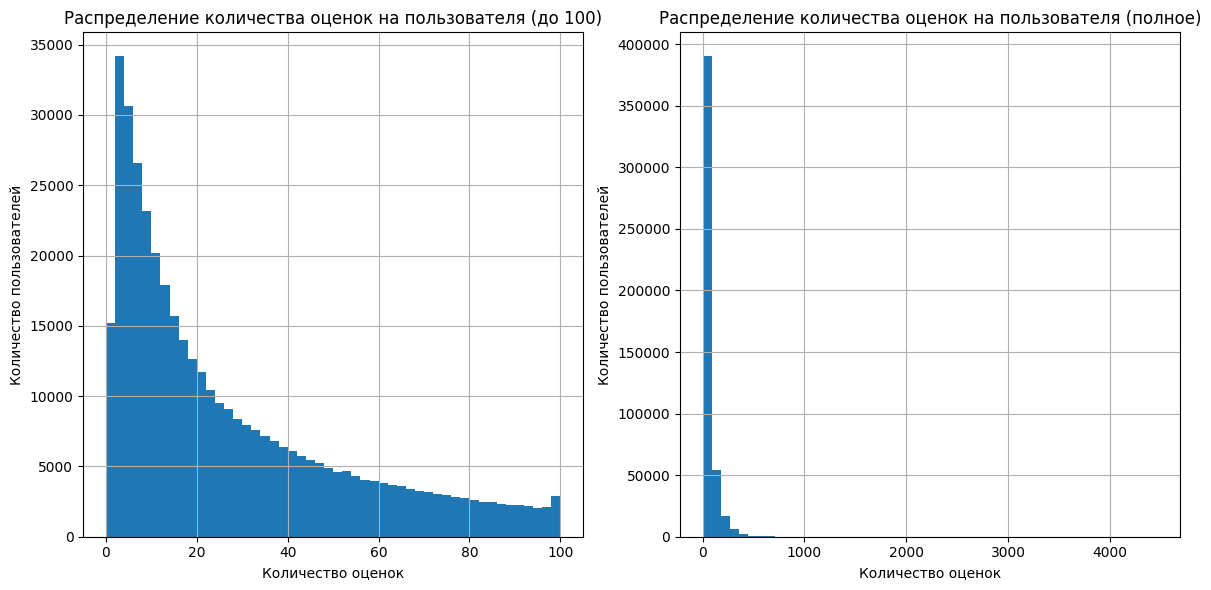

In [16]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
user_rating_counts.hist(bins=50, range=(0, 100))
plt.title('Распределение количества оценок на пользователя (до 100)')
plt.xlabel('Количество оценок')
plt.ylabel('Количество пользователей')

plt.subplot(1, 2, 2)
user_rating_counts.hist(bins=50)
plt.title('Распределение количества оценок на пользователя (полное)')
plt.xlabel('Количество оценок')
plt.ylabel('Количество пользователей')
plt.tight_layout()
plt.show()

In [17]:
print("Статистика по количеству оценок на пользователя:")
print(user_rating_counts.describe())

Статистика по количеству оценок на пользователя:
count    470758.000000
mean         51.095414
std          74.403998
min           1.000000
25%           8.000000
50%          24.000000
75%          64.000000
max        4466.000000
Name: count, dtype: float64


### number of ratings

In [18]:
movie_rating_counts = df['movie_id'].value_counts()

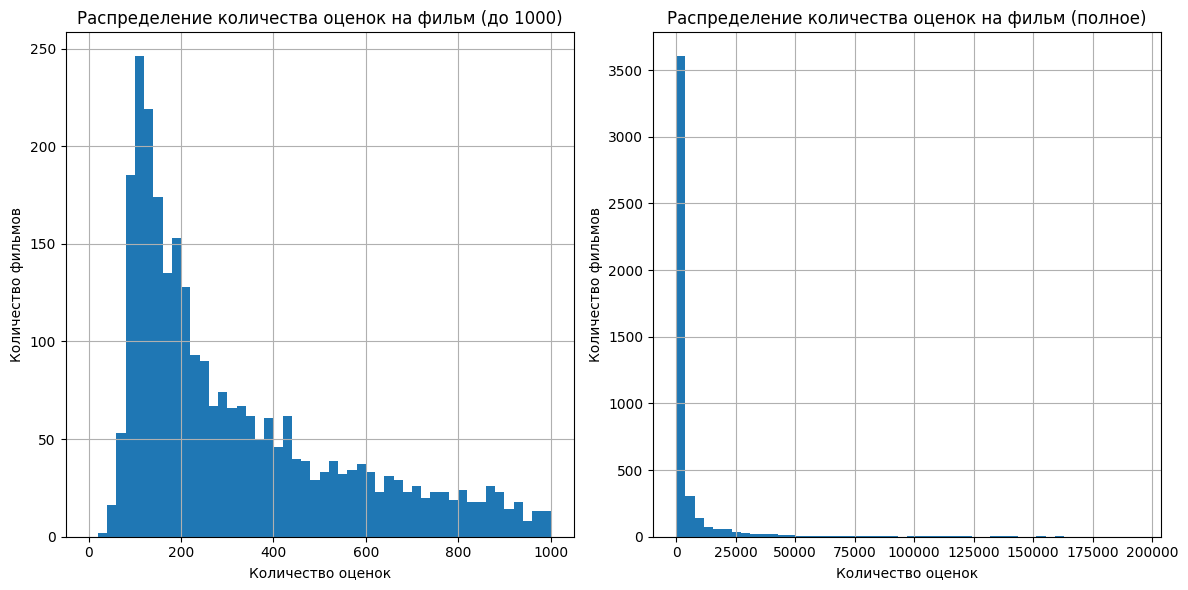

In [19]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
movie_rating_counts.hist(bins=50, range=(0, 1000))
plt.title('Распределение количества оценок на фильм (до 1000)')
plt.xlabel('Количество оценок')
plt.ylabel('Количество фильмов')

plt.subplot(1, 2, 2)
movie_rating_counts.hist(bins=50)
plt.title('Распределение количества оценок на фильм (полное)')
plt.xlabel('Количество оценок')
plt.ylabel('Количество фильмов')
plt.tight_layout()
plt.show()

In [20]:
print("Статистика по количеству оценок на фильм:")
print(movie_rating_counts.describe())

Статистика по количеству оценок на фильм:
count      4498.000000
mean       5347.615607
std       16177.929470
min          36.000000
25%         192.000000
50%         552.500000
75%        2539.000000
max      193941.000000
Name: count, dtype: float64


### activity by date

In [21]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

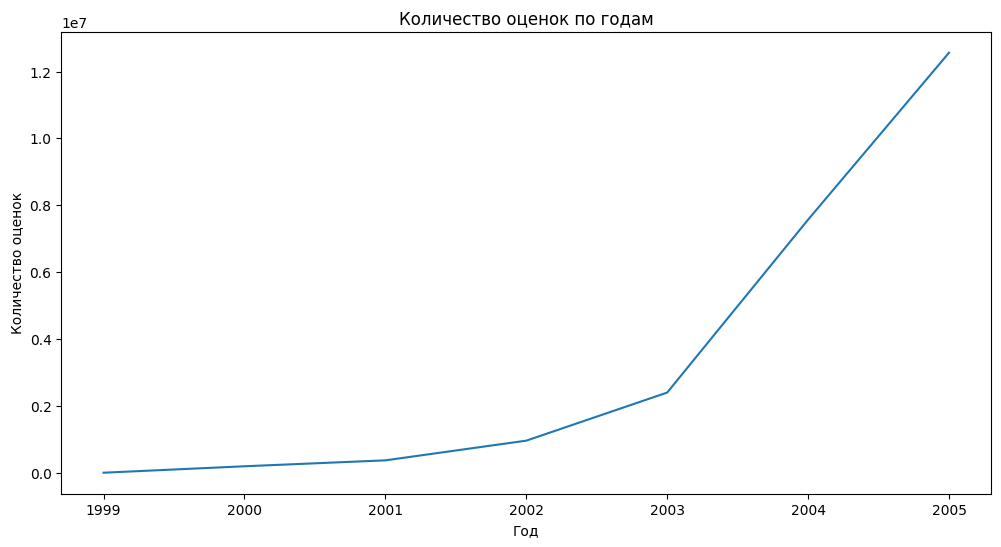

In [22]:
ratings_by_year = df.groupby('year').size()
plt.figure(figsize=(12, 6))
ratings_by_year.plot()
plt.title('Количество оценок по годам')
plt.xlabel('Год')
plt.ylabel('Количество оценок')
plt.show()

### movies by year

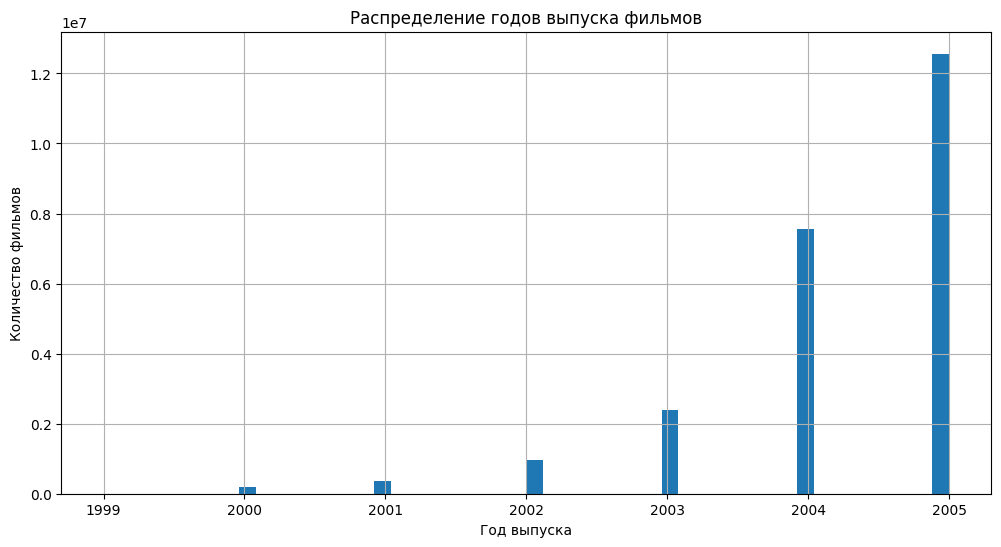

In [23]:
plt.figure(figsize=(12, 6))
df['year'].hist(bins=50)
plt.title('Распределение годов выпуска фильмов')
plt.xlabel('Год выпуска')
plt.ylabel('Количество фильмов')
plt.show()

## Models

### Data preporation

In [24]:
min_user_ratings = 52
min_movie_ratings = 1800

user_counts = df['user_id'].value_counts()
movie_counts = df['movie_id'].value_counts()

filtered_users = user_counts[user_counts >= min_user_ratings].index
filtered_movies = movie_counts[movie_counts >= min_movie_ratings].index

df_filtered = df[df['user_id'].isin(filtered_users) & df['movie_id'].isin(filtered_movies)]
print(f"Данные после фильтрации: {df_filtered.shape}")

Данные после фильтрации: (17334645, 7)


In [25]:
train_data, test_data = train_test_split(df_filtered, test_size=0.2, random_state=42, stratify=df_filtered['user_id'])

user_ids = train_data['user_id'].unique()
movie_ids = train_data['movie_id'].unique()

user_to_idx = {user_id: idx for idx, user_id in enumerate(user_ids)}
movie_to_idx = {movie_id: idx for idx, movie_id in enumerate(movie_ids)}
idx_to_movie = {idx: movie_id for movie_id, idx in movie_to_idx.items()}

train_matrix = sparse.csr_matrix((train_data['rating'].values,
                                (train_data['user_id'].map(user_to_idx).values,
                                 train_data['movie_id'].map(movie_to_idx).values)),
                                shape=(len(user_ids), len(movie_ids)))

print(f"Матрица взаимодействий: {train_matrix.shape}")
print(f"Заполненность: {(train_matrix.nnz / (train_matrix.shape[0] * train_matrix.shape[1]) * 100):.4f}%")

Матрица взаимодействий: (143457, 1348)
Заполненность: 7.1712%


### MostPop

In [26]:
class MostPop:
    def __init__(self):
        self.popular_items = None

    def fit(self, df):
        item_scores = df.groupby('movie_id').agg({
            'rating': ['mean', 'count']
        })
        item_scores.columns = ['avg_rating', 'count']
        item_scores['score'] = item_scores['avg_rating'] * np.log1p(item_scores['count'])
        self.popular_items = item_scores['score'].sort_values(ascending=False)

    def recommend(self, user_id, n=10):
        return self.popular_items.head(n).index.tolist()

mostpop = MostPop()
mostpop.fit(train_data)

### ItemKNN

In [27]:
class ItemKNN:
    def __init__(self, k=30):
        self.k = k
        self.item_similarity = None
        self.train_matrix = None
        self.user_to_idx = None
        self.movie_to_idx = None
        self.idx_to_movie = None

    def fit(self, train_matrix, user_to_idx, movie_to_idx, movie_ids):
        self.train_matrix = train_matrix
        self.user_to_idx = user_to_idx
        self.movie_to_idx = movie_to_idx
        self.idx_to_movie = {idx: movie_id for idx, movie_id in enumerate(movie_ids)}

        print("Вычисление Item-Item схожести...")
        self.item_similarity = cosine_similarity(train_matrix.T)

    def recommend(self, user_id, n=10):
        if user_id not in self.user_to_idx:
            return self._get_fallback_recommendations(n)

        user_idx = self.user_to_idx[user_id]
        user_ratings = self.train_matrix[user_idx].toarray().flatten()

        rated_items = user_ratings.nonzero()[0]

        if len(rated_items) == 0:
            return self._get_fallback_recommendations(n)

        item_scores = np.zeros(self.train_matrix.shape[1])

        for rated_item in rated_items:
            rating = user_ratings[rated_item]
            similar_items = np.argsort(self.item_similarity[rated_item])[::-1][1:self.k+1]

            for sim_item in similar_items:
                if user_ratings[sim_item] == 0 and self.item_similarity[rated_item, sim_item] > 0:
                    item_scores[sim_item] += self.item_similarity[rated_item, sim_item] * rating

        item_scores[rated_items] = -np.inf

        top_items = np.argsort(item_scores)[::-1][:n]
        return [self.idx_to_movie[item_idx] for item_idx in top_items if item_scores[item_idx] > 0]

    def _get_fallback_recommendations(self, n):
        return list(self.idx_to_movie.values())[:n]


itemknn = ItemKNN(k=30)
itemknn.fit(train_matrix, user_to_idx, movie_to_idx, movie_ids)

Вычисление Item-Item схожести...


### ALS

In [28]:
class ALS:
    def __init__(self, factors=20, iterations=10, regularization=0.1):
        self.factors = factors
        self.iterations = iterations
        self.regularization = regularization
        self.user_factors = None
        self.item_factors = None
        self.user_to_idx = None
        self.idx_to_movie = None

    def fit(self, train_matrix, user_to_idx, movie_ids):
        self.user_to_idx = user_to_idx
        self.idx_to_movie = {idx: movie_id for idx, movie_id in enumerate(movie_ids)}

        n_users, n_items = train_matrix.shape

        self.user_factors = np.random.normal(0, 0.1, (n_users, self.factors))
        self.item_factors = np.random.normal(0, 0.1, (n_items, self.factors))

        print("Обучение ALS...")
        for iteration in range(self.iterations):
            for u in range(n_users):
                user_ratings = train_matrix[u].toarray().flatten()
                rated_items = user_ratings.nonzero()[0]

                if len(rated_items) > 0:
                    A = self.item_factors[rated_items].T @ self.item_factors[rated_items]
                    A += self.regularization * np.eye(self.factors)
                    b = self.item_factors[rated_items].T @ user_ratings[rated_items]
                    self.user_factors[u] = np.linalg.solve(A, b)

            for i in range(n_items):
                item_ratings = train_matrix[:, i].toarray().flatten()
                rated_users = item_ratings.nonzero()[0]

                if len(rated_users) > 0:
                    A = self.user_factors[rated_users].T @ self.user_factors[rated_users]
                    A += self.regularization * np.eye(self.factors)
                    b = self.user_factors[rated_users].T @ item_ratings[rated_users]
                    self.item_factors[i] = np.linalg.solve(A, b)

            print(f"  Итерация {iteration + 1}/{self.iterations}")

    def recommend(self, user_id, n=10):
        if user_id not in self.user_to_idx:
            return self._get_fallback_recommendations(n)

        user_idx = self.user_to_idx[user_id]

        scores = self.user_factors[user_idx] @ self.item_factors.T

        user_ratings = self.train_matrix[user_idx].toarray().flatten()
        rated_items = user_ratings.nonzero()[0]
        scores[rated_items] = -np.inf

        top_items = np.argsort(scores)[::-1][:n]
        return [self.idx_to_movie[item_idx] for item_idx in top_items]

    def _get_fallback_recommendations(self, n):
        return list(self.idx_to_movie.values())[:n]


als = ALS(factors=20, iterations=10, regularization=0.05)
als.train_matrix = train_matrix
als.fit(train_matrix, user_to_idx, movie_ids)

Обучение ALS...
  Итерация 1/10
  Итерация 2/10
  Итерация 3/10
  Итерация 4/10
  Итерация 5/10
  Итерация 6/10
  Итерация 7/10
  Итерация 8/10
  Итерация 9/10
  Итерация 10/10


## Metrics

In [41]:
def precision_at_k(recommended_items, relevant_items, k=10):
    if not recommended_items:
        return 0.0
    recommended_k = recommended_items[:k]
    relevant_set = set(relevant_items)
    hits = sum(1 for item in recommended_k if item in relevant_set)
    return hits / len(recommended_k)

def recall_at_k(recommended_items, relevant_items, k=10):
    if not relevant_items or not recommended_items:
        return 0.0
    recommended_k = recommended_items[:k]
    relevant_set = set(relevant_items)
    hits = sum(1 for item in recommended_k if item in relevant_set)
    return hits / len(relevant_set)

def ap_at_k(recommended_items, relevant_items, k=10):
    if not relevant_items or not recommended_items:
        return 0.0
    relevant_set = set(relevant_items)
    hits = 0
    sum_precisions = 0
    for i, item in enumerate(recommended_items[:k]):
        if item in relevant_set:
            hits += 1
            sum_precisions += hits / (i + 1)
    return sum_precisions / min(len(relevant_set), k)

def map_at_k(all_recommendations, all_relevant_items, k=10):
    if not all_recommendations:
        return 0.0
    ap_scores = []
    for user_rec, user_rel in zip(all_recommendations, all_relevant_items):
        ap_scores.append(ap_at_k(user_rec, user_rel, k))
    return np.mean(ap_scores)

In [42]:
def novelty(recommended_items, item_popularity):
    if not recommended_items:
        return 0.0
    novelty_score = 0
    total_ratings = sum(item_popularity.values())
    for item in recommended_items:
        popularity = item_popularity.get(item, 0)
        p = (popularity + 1) / (total_ratings + 1)
        novelty_score += -np.log2(p)
    return novelty_score / len(recommended_items)

In [43]:
test_users = test_data['user_id'].unique()[:500]
item_popularity = train_data['movie_id'].value_counts().to_dict()

def get_user_ratings(df, user_id):
    return df[df['user_id'] == user_id]['movie_id'].tolist()

In [44]:
models = {
    'MostPop': mostpop,
    'ItemKNN': itemknn,
    'ALS': als
}

results = {}

In [54]:
for model_name, model in models.items():
    print(f"Оценка {model_name}...")

    precisions = []
    recalls = []
    novelties = []
    all_recommendations = []
    all_relevant = []

    evaluated_users = 0

    for user in test_users:
        user_ratings = get_user_ratings(test_data, user)

        if len(user_ratings) < 2:
            continue

        try:
            recommended = model.recommend(user, 10)

            if not recommended:
                continue

            prec = precision_at_k(recommended, user_ratings)
            rec = recall_at_k(recommended, user_ratings)
            nov = novelty(recommended, item_popularity)

            precisions.append(prec)
            recalls.append(rec)
            novelties.append(nov)
            all_recommendations.append(recommended)
            all_relevant.append(user_ratings)
            evaluated_users += 1

        except Exception as e:
            continue

    map_score = map_at_k(all_recommendations, all_relevant) if all_recommendations else 0

    results[model_name] = {
        'Precision@10': np.mean(precisions) if precisions else 0,
        'Recall@10': np.mean(recalls) if recalls else 0,
        'Novelty': np.mean(novelties) if novelties else 0,
        'MAP@10': map_score,
        'Evaluated_Users': evaluated_users
    }

    print(f"{model_name}: Precision={results[model_name]['Precision@10']:.4f}, "
          f"Recall={results[model_name]['Recall@10']:.4f}, "
          f"Novelty={results[model_name]['Novelty']:.4f}")

Оценка MostPop...
MostPop: Precision=0.1396, Recall=0.0510, Novelty=7.6714
Оценка ItemKNN...
ItemKNN: Precision=0.4482, Recall=0.1431, Novelty=7.7034
Оценка ALS...
ALS: Precision=0.0866, Recall=0.0224, Novelty=11.7297


In [52]:
results_df = pd.DataFrame(results).T
print("Результаты сравнения методов:")
print(results_df)

Результаты сравнения методов:
         Precision@10  Recall@10    Novelty    MAP@10  Evaluated_Users
MostPop        0.1396   0.050987   7.671403  0.057532            500.0
ItemKNN        0.4482   0.143115   7.703448  0.343759            500.0
ALS            0.0866   0.022410  11.729700  0.041680            500.0


## Result

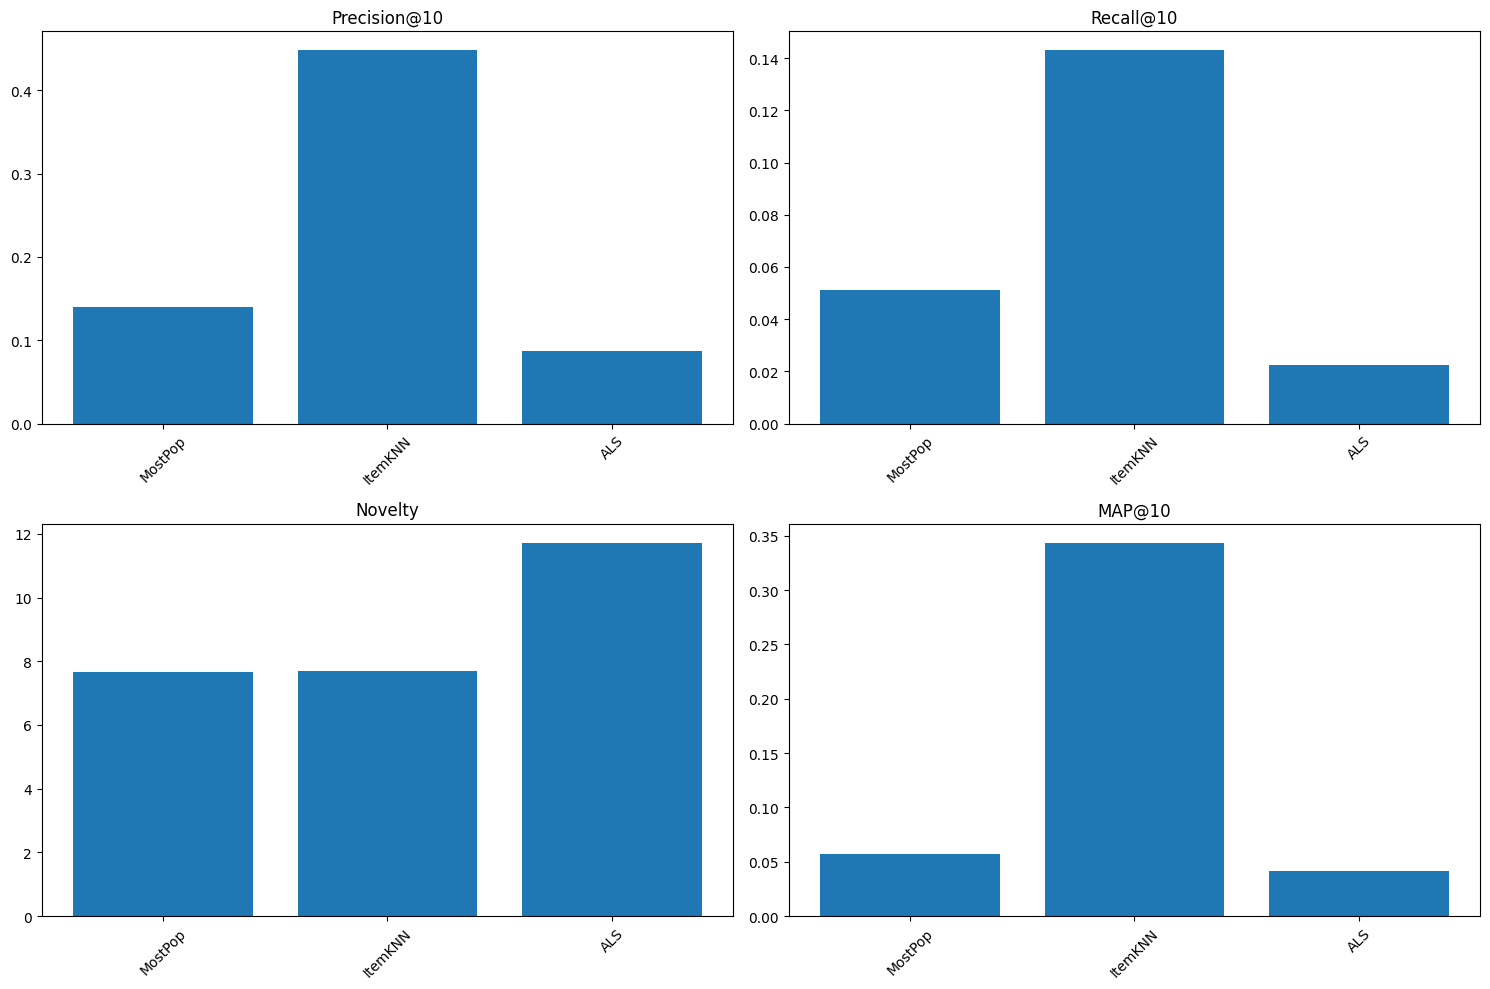

In [53]:
plt.figure(figsize=(15, 10))

metrics = ['Precision@10', 'Recall@10', 'Novelty', 'MAP@10']
for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    plt.bar(results_df.index, results_df[metric])
    plt.title(metric)
    plt.xticks(rotation=45)
    plt.tight_layout()

plt.show()